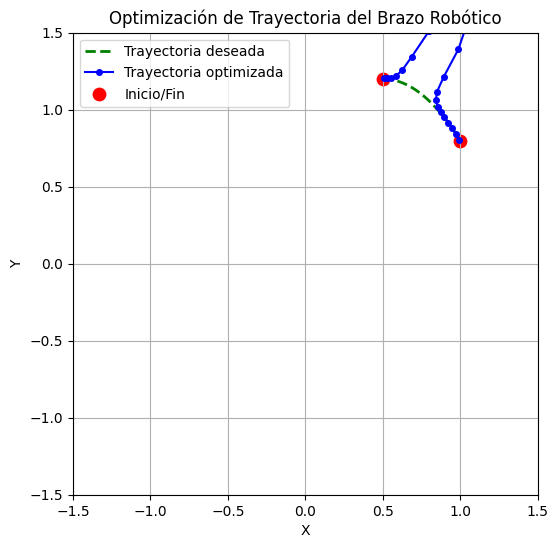

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# **Parámetros del brazo robótico**
L1, L2 = 1.0, 1.0  # Longitudes de los eslabones

# **Definimos la trayectoria deseada (ejemplo: parábola)**
T = 20  # Número de pasos de tiempo
t_vals = np.linspace(0, 1, T)

# Trayectoria deseada: parábola en el espacio (x, y)
x_deseado = 0.5 + 0.5 * t_vals
y_deseado = 1.2 - 0.4 * t_vals**2

# **Función de cinemática directa (vectorizada)**
@np.vectorize
def forward_kinematics(theta1, theta2):
    x = L1 * np.cos(theta1) + L2 * np.cos(theta1 + theta2)
    y = L1 * np.sin(theta1) + L2 * np.sin(theta1 + theta2)
    return x, y

# **Función objetivo optimizada**
def objective_function(thetas):
    theta1_seq, theta2_seq = thetas[:T], thetas[T:]

    # Calcular la trayectoria obtenida en una sola iteración
    x_fk, y_fk = forward_kinematics(theta1_seq, theta2_seq)

    # Error de trayectoria
    error_trayectoria = np.sum((x_fk - x_deseado)**2 + (y_fk - y_deseado)**2)

    # Penalización por suavidad
    suavidad = np.sum(np.diff(theta1_seq)**2 + np.diff(theta2_seq)**2)

    return error_trayectoria + 0.5 * suavidad

# **Optimización de trayectoria**
theta_initial = np.random.uniform(-np.pi, np.pi, 2*T)  # Inicialización aleatoria
bounds = [(-np.pi, np.pi)] * (2*T)

# Optimizamos la trayectoria
theta_opt_result = minimize(objective_function, theta_initial, bounds=bounds, method='SLSQP')

# Extraer ángulos optimizados
theta1_opt, theta2_opt = theta_opt_result.x[:T], theta_opt_result.x[T:]

# **Visualización de la trayectoria optimizada**
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")

# Trayectoria deseada
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada", linewidth=2)

# Trayectoria obtenida
x_opt, y_opt = forward_kinematics(theta1_opt, theta2_opt)
ax.plot(x_opt, y_opt, 'bo-', label="Trayectoria optimizada", markersize=4)

# Puntos inicial y final resaltados
ax.scatter([x_deseado[0], x_deseado[-1]], [y_deseado[0], y_deseado[-1]], color='red', marker='o', s=80, label="Inicio/Fin")

ax.legend()
ax.set_title("Optimización de Trayectoria del Brazo Robótico")
ax.grid(True)
plt.show()


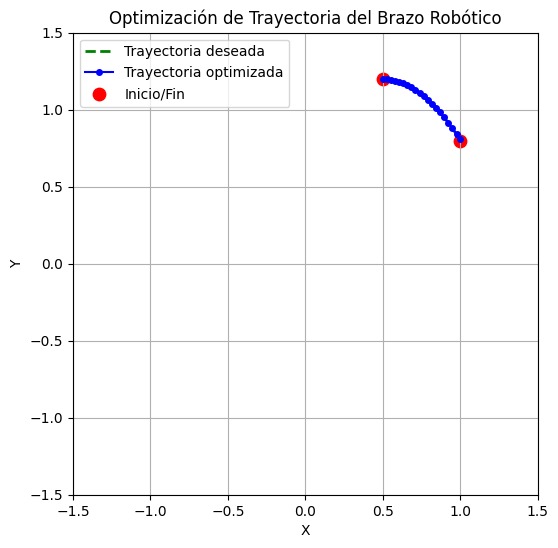

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# **Parámetros del brazo robótico**
L1, L2 = 1.0, 1.0  # Longitudes de los eslabones

# **Definimos la trayectoria deseada**
T = 20  # Número de pasos de tiempo
t_vals = np.linspace(0, 1, T)

# Trayectoria deseada: parábola en el espacio (x, y)
x_deseado = 0.5 + 0.5 * t_vals
y_deseado = 1.2 - 0.4 * t_vals**2

# **Función de cinemática directa (vectorizada)**
@np.vectorize
def forward_kinematics(theta1, theta2):
    x = L1 * np.cos(theta1) + L2 * np.cos(theta1 + theta2)
    y = L1 * np.sin(theta1) + L2 * np.sin(theta1 + theta2)
    return x, y

# **Función objetivo mejorada**
def objective_function(thetas):
    theta1_seq, theta2_seq = thetas[:T], thetas[T:]

    # Calcular la trayectoria obtenida
    x_fk, y_fk = forward_kinematics(theta1_seq, theta2_seq)

    # Error de trayectoria
    error_trayectoria = np.sum((x_fk - x_deseado)**2 + (y_fk - y_deseado)**2)

    # Penalización por cambios bruscos de posición (suavidad)
    suavidad = np.sum(np.diff(theta1_seq)**2 + np.diff(theta2_seq)**2)

    # Penalización por aceleraciones grandes (segunda derivada)
    aceleracion = np.sum(np.diff(theta1_seq, n=2)**2 + np.diff(theta2_seq, n=2)**2)

    return error_trayectoria + 0.3 * suavidad + 0.1 * aceleracion

# **Optimización de trayectoria**
theta_initial = np.random.uniform(-np.pi, np.pi, 2*T)  # Inicialización aleatoria
bounds = [(-np.pi, np.pi)] * (2*T)

# Optimizamos la trayectoria
theta_opt_result = minimize(objective_function, theta_initial, bounds=bounds, method='SLSQP')

# Extraer ángulos optimizados
theta1_opt, theta2_opt = theta_opt_result.x[:T], theta_opt_result.x[T:]

# **Visualización de la trayectoria optimizada**
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")

# Trayectoria deseada
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada", linewidth=2)

# Trayectoria obtenida
x_opt, y_opt = forward_kinematics(theta1_opt, theta2_opt)
ax.plot(x_opt, y_opt, 'bo-', label="Trayectoria optimizada", markersize=4)

# Puntos inicial y final resaltados
ax.scatter([x_deseado[0], x_deseado[-1]], [y_deseado[0], y_deseado[-1]], color='red', marker='o', s=80, label="Inicio/Fin")

ax.legend()
ax.set_title("Optimización de Trayectoria del Brazo Robótico")
ax.grid(True)
plt.show()


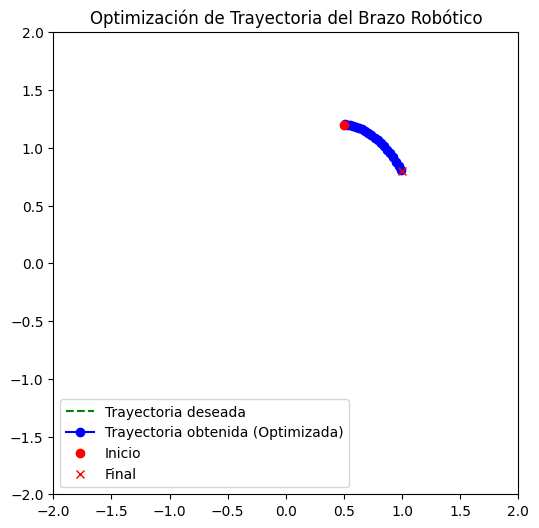

(np.float64(2.0282725880330887),
 np.float64(-1.714716529234291),
 np.float64(1.5601977135641114),
 np.float64(-1.7550485457566165))

In [11]:
# **Reejecutar código tras el reinicio del entorno**

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# **Parámetros del brazo robótico**
L1, L2 = 1.0, 1.0  # Longitudes de los eslabones

# **Definimos la trayectoria deseada (ejemplo: parábola)**
T = 20  # Número de pasos de tiempo
t_vals = np.linspace(0, 1, T)

# Trayectoria deseada: parábola en el espacio (x, y)
x_deseado = 0.5 + 0.5 * t_vals
y_deseado = 1.2 - 0.4 * t_vals**2

# **Función de cinemática directa**
def forward_kinematics(theta1, theta2):
    x = L1 * np.cos(theta1) + L2 * np.cos(theta1 + theta2)
    y = L1 * np.sin(theta1) + L2 * np.sin(theta1 + theta2)
    return x, y

# **Función objetivo: Minimizar el error de trayectoria + suavidad**
def objective_function(thetas, idx):
    theta1_seq, theta2_seq = thetas[:T], thetas[T:]
    error_trayectoria = np.sum((forward_kinematics(theta1_seq[idx], theta2_seq[idx])[0] - x_deseado[idx])**2 +
                               (forward_kinematics(theta1_seq[idx], theta2_seq[idx])[1] - y_deseado[idx])**2)
    
    # Penalización por movimientos bruscos (diferencias entre ángulos consecutivos)
    suavidad = np.sum(np.diff(theta1_seq)**2 + np.diff(theta2_seq)**2)
    
    return error_trayectoria + 0.5 * suavidad  # Ponderamos la suavidad

# **Optimización de trayectoria**
theta_initial = np.random.uniform(-np.pi, np.pi, 2*T)  # Inicialización aleatoria

# Restricciones: límites en los ángulos
bounds = [(-np.pi, np.pi)] * (2*T)

# Optimizamos cada instante de la trayectoria
theta_opt_result = minimize(objective_function, theta_initial, args=(np.arange(T)), bounds=bounds, method='SLSQP')

# Extraer ángulos optimizados
theta1_opt, theta2_opt = theta_opt_result.x[:T], theta_opt_result.x[T:]

# **Visualización de la trayectoria**
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

# Dibujar la trayectoria deseada
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada")

# Dibujar la trayectoria obtenida
x_opt, y_opt = np.zeros(T), np.zeros(T)
for i in range(T):
    x_opt[i], y_opt[i] = forward_kinematics(theta1_opt[i], theta2_opt[i])
ax.plot(x_opt, y_opt, 'bo-', label="Trayectoria obtenida (Optimizada)")

# Dibujar el punto inicial y final
ax.plot(x_deseado[0], y_deseado[0], 'ro', label="Inicio")
ax.plot(x_deseado[-1], y_deseado[-1], 'rx', label="Final")

ax.legend()
ax.set_title("Optimización de Trayectoria del Brazo Robótico")
plt.show()

# Mostrar valores de los ángulos optimizados en el primer y último punto
theta1_opt[0], theta2_opt[0], theta1_opt[-1], theta2_opt[-1]

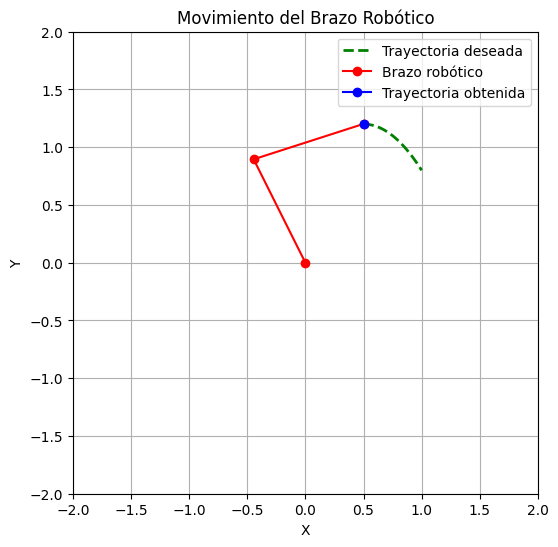

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.optimize import minimize

# **Parámetros del brazo robótico**
L1, L2 = 1.0, 1.0  # Longitudes de los eslabones

# **Trayectoria deseada**
T = 20  # Número de pasos de tiempo
t_vals = np.linspace(0, 1, T)

x_deseado = 0.5 + 0.5 * t_vals
y_deseado = 1.2 - 0.4 * t_vals**2

# **Cinemática Directa**
@np.vectorize
def forward_kinematics(theta1, theta2):
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    
    return x1, y1, x2, y2

# **Función objetivo**
def objective_function(thetas):
    theta1_seq, theta2_seq = thetas[:T], thetas[T:]
    x_fk, y_fk = forward_kinematics(theta1_seq, theta2_seq)[2:]  # Tomamos (x2, y2)

    error_trayectoria = np.sum((x_fk - x_deseado)**2 + (y_fk - y_deseado)**2)
    suavidad = np.sum(np.diff(theta1_seq)**2 + np.diff(theta2_seq)**2)
    aceleracion = np.sum(np.diff(theta1_seq, n=2)**2 + np.diff(theta2_seq, n=2)**2)

    return error_trayectoria + 0.3 * suavidad + 0.1 * aceleracion

# **Optimización**
theta_initial = np.random.uniform(-np.pi, np.pi, 2*T)
bounds = [(-np.pi, np.pi)] * (2*T)
theta_opt_result = minimize(objective_function, theta_initial, bounds=bounds, method='SLSQP')

theta1_opt, theta2_opt = theta_opt_result.x[:T], theta_opt_result.x[T:]

# **Animación de la trayectoria del brazo**
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Movimiento del Brazo Robótico")
ax.grid(True)

# Trayectoria deseada
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada", linewidth=2)

# Elementos gráficos
linea, = ax.plot([], [], 'ro-', markersize=6, label="Brazo robótico")
trayectoria_obtenida, = ax.plot([], [], 'bo-', label="Trayectoria obtenida")

def actualizar(i):
    x1, y1, x2, y2 = forward_kinematics(theta1_opt[i], theta2_opt[i])
    
    # Actualizar brazo
    linea.set_data([0, x1, x2], [0, y1, y2])
    
    # Actualizar trayectoria obtenida
    trayectoria_obtenida.set_data(forward_kinematics(theta1_opt[:i+1], theta2_opt[:i+1])[2:])
    
    return linea, trayectoria_obtenida

ani = animation.FuncAnimation(fig, actualizar, frames=T, interval=200, blit=True)
ax.legend()
plt.show()


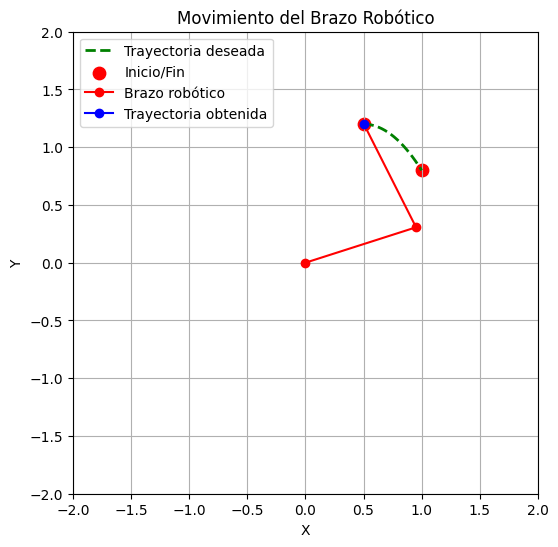

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.optimize import minimize

# **Parámetros del brazo robótico**
L1, L2 = 1.0, 1.0  # Longitudes de los eslabones

# **Trayectoria deseada**
T = 20  # Número de pasos de tiempo
t_vals = np.linspace(0, 1, T)

x_deseado = 0.5 + 0.5 * t_vals
y_deseado = 1.2 - 0.4 * t_vals**2

# **Cinemática Directa**
def forward_kinematics(theta1, theta2):
    """ Calcula las coordenadas del brazo en cada paso """
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    
    return np.array([x1, y1]), np.array([x2, y2])  # Retorna codo y punta del brazo

# **Función objetivo**
def objective_function(thetas):
    theta1_seq, theta2_seq = thetas[:T], thetas[T:]
    _, punta_fk = forward_kinematics(theta1_seq, theta2_seq)

    # Error de trayectoria
    error_trayectoria = np.sum((punta_fk[0] - x_deseado)**2 + (punta_fk[1] - y_deseado)**2)

    # Penalización por cambios bruscos de posición (suavidad)
    suavidad = np.sum(np.diff(theta1_seq)**2 + np.diff(theta2_seq)**2)

    # Penalización por aceleraciones grandes (segunda derivada)
    aceleracion = np.sum(np.diff(theta1_seq, n=2)**2 + np.diff(theta2_seq, n=2)**2)

    return error_trayectoria + 0.3 * suavidad + 0.1 * aceleracion

# **Optimización**
theta_initial = np.random.uniform(-np.pi, np.pi, 2*T)
bounds = [(-np.pi, np.pi)] * (2*T)
theta_opt_result = minimize(objective_function, theta_initial, bounds=bounds, method='SLSQP')

theta1_opt, theta2_opt = theta_opt_result.x[:T], theta_opt_result.x[T:]

# **Animación de la trayectoria del brazo**
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Movimiento del Brazo Robótico")
ax.grid(True)

# Trayectoria deseada
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada", linewidth=2)

# Puntos inicial y final resaltados
ax.scatter([x_deseado[0], x_deseado[-1]], [y_deseado[0], y_deseado[-1]], color='red', marker='o', s=80, label="Inicio/Fin")

# Elementos gráficos
linea, = ax.plot([], [], 'ro-', markersize=6, label="Brazo robótico")
trayectoria_obtenida, = ax.plot([], [], 'bo-', label="Trayectoria obtenida")

def actualizar(i):
    codo, punta = forward_kinematics(theta1_opt[i], theta2_opt[i])
    
    # Actualizar brazo
    linea.set_data([0, codo[0], punta[0]], [0, codo[1], punta[1]])
    
    # Actualizar trayectoria obtenida
    trayectoria_obtenida.set_data(forward_kinematics(theta1_opt[:i+1], theta2_opt[:i+1])[1])
    
    return linea, trayectoria_obtenida

ani = animation.FuncAnimation(fig, actualizar, frames=T, interval=200, blit=True)
ax.legend()
plt.show()


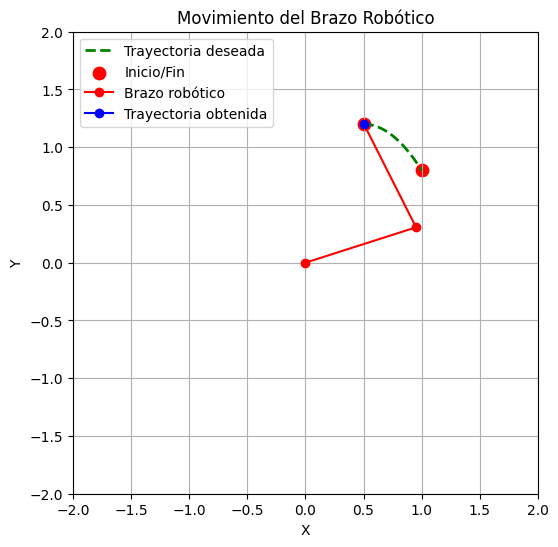

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.optimize import minimize

# **Parámetros del brazo robótico**
L1, L2 = 1.0, 1.0  # Longitudes de los eslabones

# **Trayectoria deseada**
T = 20  # Número de pasos de tiempo
t_vals = np.linspace(0, 1, T)

x_deseado = 0.5 + 0.5 * t_vals
y_deseado = 1.2 - 0.4 * t_vals**2

# **Cinemática Directa**
def forward_kinematics(theta1, theta2):
    """ Calcula las coordenadas del codo y la punta del brazo """
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    
    return np.array([x1, y1]), np.array([x2, y2])  # Retorna codo y punta del brazo

# **Función objetivo**
def objective_function(thetas):
    theta1_seq, theta2_seq = thetas[:T], thetas[T:]
    _, punta_fk = forward_kinematics(theta1_seq, theta2_seq)

    # Error de trayectoria
    error_trayectoria = np.sum((punta_fk[0] - x_deseado)**2 + (punta_fk[1] - y_deseado)**2)

    # Penalización por cambios bruscos de posición (suavidad)
    suavidad = np.sum(np.diff(theta1_seq)**2 + np.diff(theta2_seq)**2)

    # Penalización por aceleraciones grandes (segunda derivada)
    aceleracion = np.sum(np.diff(theta1_seq, n=2)**2 + np.diff(theta2_seq, n=2)**2)

    # Penalización extra para garantizar que el brazo toque el punto final
    error_final = (punta_fk[0][-1] - x_deseado[-1])**2 + (punta_fk[1][-1] - y_deseado[-1])**2

    return error_trayectoria + 0.3 * suavidad + 0.1 * aceleracion + 10 * error_final

# **Optimización**
theta_initial = np.random.uniform(-np.pi, np.pi, 2*T)
bounds = [(-np.pi, np.pi)] * (2*T)
theta_opt_result = minimize(objective_function, theta_initial, bounds=bounds, method='SLSQP')

theta1_opt, theta2_opt = theta_opt_result.x[:T], theta_opt_result.x[T:]

# **Animación de la trayectoria del brazo**
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Movimiento del Brazo Robótico")
ax.grid(True)

# Trayectoria deseada
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada", linewidth=2)

# Puntos inicial y final resaltados
ax.scatter([x_deseado[0], x_deseado[-1]], [y_deseado[0], y_deseado[-1]], color='red', marker='o', s=80, label="Inicio/Fin")

# Elementos gráficos
linea, = ax.plot([], [], 'ro-', markersize=6, label="Brazo robótico")
trayectoria_obtenida, = ax.plot([], [], 'bo-', label="Trayectoria obtenida")

def actualizar(i):
    codo, punta = forward_kinematics(theta1_opt[i], theta2_opt[i])
    
    # Actualizar brazo
    linea.set_data([0, codo[0], punta[0]], [0, codo[1], punta[1]])
    
    # Actualizar trayectoria obtenida
    puntas_optimizadas = np.array([forward_kinematics(theta1_opt[j], theta2_opt[j])[1] for j in range(i+1)])
    trayectoria_obtenida.set_data(puntas_optimizadas[:, 0], puntas_optimizadas[:, 1])
    
    return linea, trayectoria_obtenida

ani = animation.FuncAnimation(fig, actualizar, frames=T, interval=200, blit=True)
ax.legend()
plt.show()


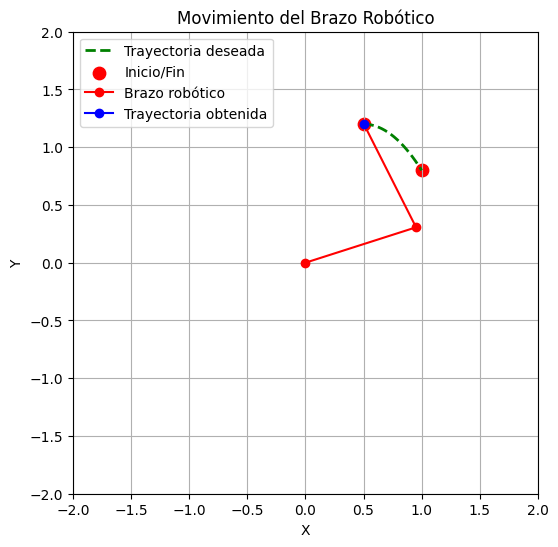

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.optimize import minimize

# **Parámetros del brazo robótico**
L1, L2 = 1.0, 1.0  # Longitudes de los eslabones

# **Trayectoria deseada**
T = 20  # Número de pasos de tiempo
t_vals = np.linspace(0, 1, T)

x_deseado = 0.5 + 0.5 * t_vals
y_deseado = 1.2 - 0.4 * t_vals**2

# **Cinemática Directa**
def forward_kinematics(theta1, theta2):
    """ Calcula las coordenadas del codo y la punta del brazo """
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    
    return np.array([x1, y1]), np.array([x2, y2])  # Retorna codo y punta del brazo

# **Función objetivo**
def objective_function(thetas):
    theta1_seq, theta2_seq = thetas[:T], thetas[T:]
    _, punta_fk = forward_kinematics(theta1_seq, theta2_seq)

    # Error de trayectoria
    error_trayectoria = np.sum((punta_fk[0] - x_deseado)**2 + (punta_fk[1] - y_deseado)**2)

    # Penalización por cambios bruscos de posición (suavidad)
    suavidad = np.sum(np.diff(theta1_seq)**2 + np.diff(theta2_seq)**2)

    # Penalización por aceleraciones grandes (segunda derivada)
    aceleracion = np.sum(np.diff(theta1_seq, n=2)**2 + np.diff(theta2_seq, n=2)**2)

    # Penalización extra para garantizar que el brazo toque el punto final
    error_final = (punta_fk[0][-1] - x_deseado[-1])**2 + (punta_fk[1][-1] - y_deseado[-1])**2

    return error_trayectoria + 0.3 * suavidad + 0.1 * aceleracion + 10 * error_final

# **Optimización**
theta_initial = np.random.uniform(-np.pi, np.pi, 2*T)
bounds = [(-np.pi, np.pi)] * (2*T)
theta_opt_result = minimize(objective_function, theta_initial, bounds=bounds, method='SLSQP')

theta1_opt, theta2_opt = theta_opt_result.x[:T], theta_opt_result.x[T:]

# **Animación de la trayectoria del brazo**
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Movimiento del Brazo Robótico")
ax.grid(True)

# **Dibujamos la trayectoria deseada**
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada", linewidth=2)

# **Puntos inicial y final resaltados**
ax.scatter([x_deseado[0], x_deseado[-1]], [y_deseado[0], y_deseado[-1]], 
           color='red', marker='o', s=80, label="Inicio/Fin")

# **Elementos gráficos**
brazo, = ax.plot([], [], 'ro-', markersize=6, label="Brazo robótico")  # Brazo
trayectoria_obtenida, = ax.plot([], [], 'bo-', label="Trayectoria obtenida")  # Trayectoria obtenida

# **Función de actualización de la animación**
def actualizar(i):
    codo, punta = forward_kinematics(theta1_opt[i], theta2_opt[i])
    
    # **Actualizar el dibujo del brazo**
    brazo.set_data([0, codo[0], punta[0]], [0, codo[1], punta[1]])
    
    # **Actualizar la trayectoria obtenida (acumulando puntos)**
    puntas_optimizadas = np.array([forward_kinematics(theta1_opt[j], theta2_opt[j])[1] for j in range(i+1)])
    trayectoria_obtenida.set_data(puntas_optimizadas[:, 0], puntas_optimizadas[:, 1])
    
    return brazo, trayectoria_obtenida

# **Crear la animación**
ani = animation.FuncAnimation(fig, actualizar, frames=T, interval=200, blit=True)
ax.legend()
plt.show()


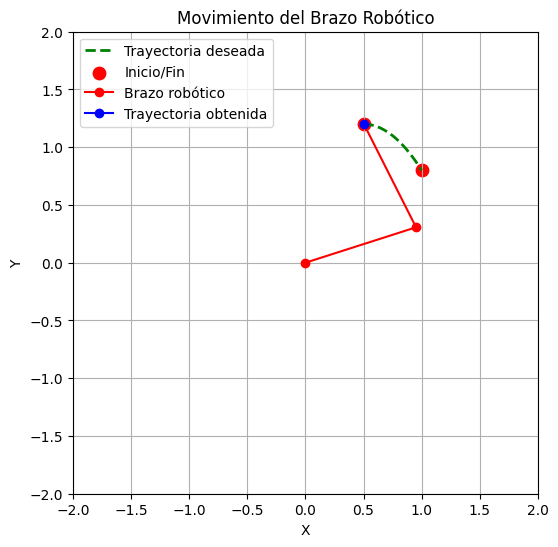

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.optimize import minimize

# **Parámetros del brazo robótico**
L1, L2 = 1.0, 1.0  # Longitudes de los eslabones

# **Trayectoria deseada**
T = 20  # Número de pasos de tiempo
t_vals = np.linspace(0, 1, T)

x_deseado = 0.5 + 0.5 * t_vals
y_deseado = 1.2 - 0.4 * t_vals**2

# **Cinemática Directa**
def forward_kinematics(theta1, theta2):
    """ Calcula las coordenadas del codo y la punta del brazo """
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    
    return np.array([x1, y1]), np.array([x2, y2])  # Retorna codo y punta del brazo

# **Función objetivo**
def objective_function(thetas):
    theta1_seq, theta2_seq = thetas[:T], thetas[T:]
    _, punta_fk = forward_kinematics(theta1_seq, theta2_seq)

    # Error de trayectoria
    error_trayectoria = np.sum((punta_fk[0] - x_deseado)**2 + (punta_fk[1] - y_deseado)**2)

    # Penalización por cambios bruscos de posición (suavidad)
    suavidad = np.sum(np.diff(theta1_seq)**2 + np.diff(theta2_seq)**2)

    # Penalización por aceleraciones grandes (segunda derivada)
    aceleracion = np.sum(np.diff(theta1_seq, n=2)**2 + np.diff(theta2_seq, n=2)**2)

    return error_trayectoria + 0.3 * suavidad + 0.1 * aceleracion

# **Optimización**
theta_initial = np.random.uniform(-np.pi, np.pi, 2*T)
bounds = [(-np.pi, np.pi)] * (2*T)
theta_opt_result = minimize(objective_function, theta_initial, bounds=bounds, method='SLSQP')

theta1_opt, theta2_opt = theta_opt_result.x[:T], theta_opt_result.x[T:]

# **Preparar la animación**
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Movimiento del Brazo Robótico")
ax.grid(True)

# **Dibujar la trayectoria deseada**
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada", linewidth=2)

# **Dibujar los puntos de inicio y fin**
ax.scatter([x_deseado[0], x_deseado[-1]], [y_deseado[0], y_deseado[-1]], 
           color='red', marker='o', s=80, label="Inicio/Fin")

# **Líneas del brazo robótico**
brazo, = ax.plot([], [], 'ro-', markersize=6, label="Brazo robótico")
trayectoria_obtenida, = ax.plot([], [], 'bo-', label="Trayectoria obtenida")

# **Función de actualización para la animación**
def actualizar(i):
    codo, punta = forward_kinematics(theta1_opt[i], theta2_opt[i])
    
    # **Dibujar el brazo en cada frame**
    brazo.set_data([0, codo[0], punta[0]], [0, codo[1], punta[1]])
    
    # **Dibujar la trayectoria optimizada**
    puntas_optimizadas = np.array([forward_kinematics(theta1_opt[j], theta2_opt[j])[1] for j in range(i+1)])
    trayectoria_obtenida.set_data(puntas_optimizadas[:, 0], puntas_optimizadas[:, 1])
    
    return brazo, trayectoria_obtenida

# **Crear la animación**
ani = animation.FuncAnimation(fig, actualizar, frames=T, interval=500, blit=True)
ax.legend()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.optimize import minimize

# Parámetros del brazo robótico
L1, L2 = 1.0, 1.0  # Longitudes de los eslabones

# Trayectoria deseada
T = 20  # Número de pasos de tiempo
t_vals = np.linspace(0, 1, T)

x_deseado = 0.5 + 0.5 * t_vals
y_deseado = 1.2 - 0.4 * t_vals**2

# Cinemática Directa
def forward_kinematics(theta1, theta2):
    """ Calcula las coordenadas del codo y la punta del brazo """
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    
    return (x1, y1), (x2, y2)

# Función objetivo para la optimización
def objective_function(thetas):
    theta1_seq, theta2_seq = thetas[:T], thetas[T:]
    _, punta_fk = zip(*[forward_kinematics(theta1_seq[i], theta2_seq[i]) for i in range(T)])

    x_fk, y_fk = np.array(punta_fk).T
    error_trayectoria = np.sum((x_fk - x_deseado)**2 + (y_fk - y_deseado)**2)
    suavidad = np.sum(np.diff(theta1_seq)**2 + np.diff(theta2_seq)**2)
    aceleracion = np.sum(np.diff(theta1_seq, n=2)**2 + np.diff(theta2_seq, n=2)**2)

    return error_trayectoria + 0.3 * suavidad + 0.1 * aceleracion

# Optimización
theta_initial = np.random.uniform(-np.pi, np.pi, 2*T)
bounds = [(-np.pi, np.pi)] * (2*T)
theta_opt_result = minimize(objective_function, theta_initial, bounds=bounds, method='SLSQP')

theta1_opt, theta2_opt = theta_opt_result.x[:T], theta_opt_result.x[T:]

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Movimiento del Brazo Robótico")
ax.grid(True)

# Dibujar la trayectoria deseada
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada", linewidth=2)

# Puntos de inicio y fin
ax.scatter([x_deseado[0], x_deseado[-1]], [y_deseado[0], y_deseado[-1]], 
           color='red', marker='o', s=80, label="Inicio/Fin")

# Líneas y puntos del brazo
brazo, = ax.plot([], [], 'ro-', markersize=6, label="Brazo robótico")
trayectoria_obtenida, = ax.plot([], [], 'bo-', label="Trayectoria obtenida")

# Función de actualización para la animación
def actualizar(i):
    codo, punta = forward_kinematics(theta1_opt[i], theta2_opt[i])
    
    brazo.set_data([0, codo[0], punta[0]], [0, codo[1], punta[1]])
    
    puntas_optimizadas = np.array([forward_kinematics(theta1_opt[j], theta2_opt[j])[1] for j in range(i+1)])
    trayectoria_obtenida.set_data(puntas_optimizadas[:, 0], puntas_optimizadas[:, 1])
    
    return brazo, trayectoria_obtenida

# Crear la animación
ani = animation.FuncAnimation(fig, actualizar, frames=T, interval=200, blit=True)
plt.legend()
plt.show()


C:\Users\alvar\AppData\Local\Temp\ipykernel_14980\651464806.py:81: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.optimize import minimize
from IPython.display import HTML  # Para visualizar la animación en VS Code

# Activar modo interactivo en Jupyter Notebook
%matplotlib notebook  

# Parámetros del brazo robótico
L1, L2 = 1.0, 1.0  

# Trayectoria deseada
T = 20  
t_vals = np.linspace(0, 1, T)
x_deseado = 0.5 + 0.5 * t_vals
y_deseado = 1.2 - 0.4 * t_vals**2

# Cinemática Directa
def forward_kinematics(theta1, theta2):
    """ Calcula las coordenadas del codo y la punta del brazo """
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    return (x1, y1), (x2, y2)

# Función objetivo para la optimización
def objective_function(thetas):
    theta1_seq, theta2_seq = thetas[:T], thetas[T:]
    _, punta_fk = zip(*[forward_kinematics(theta1_seq[i], theta2_seq[i]) for i in range(T)])
    x_fk, y_fk = np.array(punta_fk).T
    error_trayectoria = np.sum((x_fk - x_deseado)**2 + (y_fk - y_deseado)**2)
    suavidad = np.sum(np.diff(theta1_seq)**2 + np.diff(theta2_seq)**2)
    aceleracion = np.sum(np.diff(theta1_seq, n=2)**2 + np.diff(theta2_seq, n=2)**2)
    return error_trayectoria + 0.5 * suavidad + 0.1 * aceleracion

# Optimización
theta_initial = np.random.uniform(-np.pi, np.pi, 2*T)
bounds = [(-np.pi, np.pi)] * (2*T)
theta_opt_result = minimize(objective_function, theta_initial, bounds=bounds, method='SLSQP')

theta1_opt, theta2_opt = theta_opt_result.x[:T], theta_opt_result.x[T:]

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Movimiento del Brazo Robótico")
ax.grid(True)

# Dibujar la trayectoria deseada
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada", linewidth=2)

# Puntos de inicio y fin
ax.scatter([x_deseado[0], x_deseado[-1]], [y_deseado[0], y_deseado[-1]], 
           color='red', marker='o', s=80, label="Inicio/Fin")

# Líneas y puntos del brazo
brazo, = ax.plot([], [], 'ro-', markersize=6, label="Brazo robótico")
trayectoria_obtenida, = ax.plot([], [], 'bo-', label="Trayectoria obtenida")

# Función de actualización para la animación
def actualizar(i):
    codo, punta = forward_kinematics(theta1_opt[i], theta2_opt[i])
    
    brazo.set_data([0, codo[0], punta[0]], [0, codo[1], punta[1]])
    
    puntas_optimizadas = np.array([forward_kinematics(theta1_opt[j], theta2_opt[j])[1] for j in range(i+1)])
    trayectoria_obtenida.set_data(puntas_optimizadas[:, 0], puntas_optimizadas[:, 1])
    
    return brazo, trayectoria_obtenida

# Crear la animación
ani = animation.FuncAnimation(fig, actualizar, frames=T, interval=200, blit=True)
plt.legend()

# Mostrar animación en Jupyter Notebook
HTML(ani.to_jshtml())


<IPython.core.display.Javascript object>

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.optimize import minimize
from IPython.display import HTML

# Activar modo interactivo en Jupyter Notebook
%matplotlib notebook

# Parámetros del brazo robótico
L1, L2 = 1.0, 1.0  

# Trayectoria deseada
T = 20  
t_vals = np.linspace(0, 1, T)
x_deseado = 0.5 + 0.5 * t_vals
y_deseado = 1.2 - 0.4 * t_vals**2

# Cinemática Directa
def forward_kinematics(theta1, theta2):
    """ Calcula las coordenadas del codo y la punta del brazo """
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    return (x1, y1), (x2, y2)

# Función objetivo para la optimización
def objective_function(thetas):
    theta1_seq, theta2_seq = thetas[:T], thetas[T:]
    _, punta_fk = zip(*[forward_kinematics(theta1_seq[i], theta2_seq[i]) for i in range(T)])
    x_fk, y_fk = np.array(punta_fk).T
    error_trayectoria = np.sum((x_fk - x_deseado)**2 + (y_fk - y_deseado)**2)
    suavidad = np.sum(np.diff(theta1_seq)**2 + np.diff(theta2_seq)**2)
    aceleracion = np.sum(np.diff(theta1_seq, n=2)**2 + np.diff(theta2_seq, n=2)**2)
    return error_trayectoria + 0.3 * suavidad + 0.1 * aceleracion

# Optimización
theta_initial = np.random.uniform(-np.pi, np.pi, 2*T)
bounds = [(-np.pi, np.pi)] * (2*T)
theta_opt_result = minimize(objective_function, theta_initial, bounds=bounds, method='SLSQP')

theta1_opt, theta2_opt = theta_opt_result.x[:T], theta_opt_result.x[T:]

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Movimiento del Brazo Robótico")
ax.grid(True)

# Dibujar la trayectoria deseada
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada", linewidth=2)

# Puntos de inicio y fin
ax.scatter([x_deseado[0], x_deseado[-1]], [y_deseado[0], y_deseado[-1]], 
           color='red', marker='o', s=80, label="Inicio/Fin")

# Líneas y puntos del brazo
brazo, = ax.plot([], [], 'ro-', markersize=6, label="Brazo robótico")
trayectoria_obtenida, = ax.plot([], [], 'bo-', label="Trayectoria obtenida")

# Texto para mostrar el ángulo
angulo_texto = ax.text(0.5, 1.5, "", fontsize=12, ha='center', va='center', color='black')

# Función de actualización para la animación
def actualizar(i):
    codo, punta = forward_kinematics(theta1_opt[i], theta2_opt[i])
    
    brazo.set_data([0, codo[0], punta[0]], [0, codo[1], punta[1]])
    
    puntas_optimizadas = np.array([forward_kinematics(theta1_opt[j], theta2_opt[j])[1] for j in range(i+1)])
    trayectoria_obtenida.set_data(puntas_optimizadas[:, 0], puntas_optimizadas[:, 1])
    
    # Calcular el ángulo entre los dos segmentos (en radianes)
    angulo = theta2_opt[i]  # El ángulo entre los dos segmentos es theta2 en cada paso
    
    # Convertir a grados para mostrarlo de forma más comprensible
    angulo_grados = np.degrees(angulo)
    
    # Actualizar el texto con el valor del ángulo
    angulo_texto.set_text(f"Ángulo: {angulo_grados:.2f}°")
    
    return brazo, trayectoria_obtenida, angulo_texto

# Crear la animación
ani = animation.FuncAnimation(fig, actualizar, frames=T, interval=200, blit=True)
plt.legend()

# Mostrar animación en Jupyter Notebook
HTML(ani.to_jshtml())


c:\Users\alvar\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


<IPython.core.display.Javascript object>

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.optimize import minimize
from IPython.display import HTML

# Activar modo interactivo en Jupyter Notebook
%matplotlib notebook

# Parámetros del brazo robótico
L1, L2 = 1.0, 1.0  

# Trayectoria deseada
T = 20  
t_vals = np.linspace(0, 1, T)
x_deseado = 0.5 + 0.5 * t_vals
y_deseado = 1.2 - 0.4 * t_vals**2

# Cinemática Directa
def forward_kinematics(theta1, theta2):
    """ Calcula las coordenadas del codo y la punta del brazo """
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    return (x1, y1), (x2, y2)

# Función objetivo para la optimización
def objective_function(thetas):
    theta1_seq, theta2_seq = thetas[:T], thetas[T:]
    _, punta_fk = zip(*[forward_kinematics(theta1_seq[i], theta2_seq[i]) for i in range(T)])
    x_fk, y_fk = np.array(punta_fk).T
    error_trayectoria = np.sum((x_fk - x_deseado)**2 + (y_fk - y_deseado)**2)
    suavidad = np.sum(np.diff(theta1_seq)**2 + np.diff(theta2_seq)**2)
    aceleracion = np.sum(np.diff(theta1_seq, n=2)**2 + np.diff(theta2_seq, n=2)**2)
    return error_trayectoria + 0.5 * suavidad + 0.1 * aceleracion

# Optimización
theta_initial = np.random.uniform(-np.pi, np.pi, 2*T)
bounds = [(-np.pi, np.pi)] * (2*T)
theta_opt_result = minimize(objective_function, theta_initial, bounds=bounds, method='SLSQP')

theta1_opt, theta2_opt = theta_opt_result.x[:T], theta_opt_result.x[T:]

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Movimiento del Brazo Robótico")
ax.grid(True)

# Dibujar la trayectoria deseada
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada", linewidth=2)

# Puntos de inicio y fin
ax.scatter([x_deseado[0], x_deseado[-1]], [y_deseado[0], y_deseado[-1]], 
           color='red', marker='o', s=80, label="Inicio/Fin")

# Líneas y puntos del brazo
brazo, = ax.plot([], [], 'ro-', markersize=6, label="Brazo robótico")
trayectoria_obtenida, = ax.plot([], [], 'bo-', label="Trayectoria obtenida")

# Texto para mostrar el ángulo
angulo_texto = ax.text(0.5, 1.5, "", fontsize=12, ha='center', va='center', color='black')

# Función de actualización para la animación
def actualizar(i):
    codo, punta = forward_kinematics(theta1_opt[i], theta2_opt[i])
    
    brazo.set_data([0, codo[0], punta[0]], [0, codo[1], punta[1]])
    
    puntas_optimizadas = np.array([forward_kinematics(theta1_opt[j], theta2_opt[j])[1] for j in range(i+1)])
    trayectoria_obtenida.set_data(puntas_optimizadas[:, 0], puntas_optimizadas[:, 1])
    
    # Calcular el ángulo entre los dos segmentos (en radianes)
    angulo = theta2_opt[i]  # El ángulo entre los dos segmentos es theta2 en cada paso
    
    # Convertir el ángulo a grados
    angulo_grados = np.degrees(angulo)
    
    # Actualizar el texto con el valor del ángulo
    angulo_texto.set_text(f"Ángulo: {angulo_grados:.2f}°")
    
    return brazo, trayectoria_obtenida, angulo_texto

# Crear la animación
ani = animation.FuncAnimation(fig, actualizar, frames=T, interval=200, blit=True)
plt.legend()

# Mostrar animación en Jupyter Notebook
HTML(ani.to_jshtml())


c:\Users\alvar\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


<IPython.core.display.Javascript object>

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.optimize import minimize
from IPython.display import HTML

# Activar modo interactivo en Jupyter Notebook
%matplotlib notebook

# Parámetros del brazo robótico
L1, L2 = 1.0, 1.0  

# Trayectoria deseada
T = 20  
t_vals = np.linspace(0, 1, T)
x_deseado = 0.5 + 0.5 * t_vals
y_deseado = 1.2 - 0.4 * t_vals**2

# Cinemática Directa
def forward_kinematics(theta1, theta2):
    """ Calcula las coordenadas del codo y la punta del brazo """
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    return (x1, y1), (x2, y2)

# Función objetivo para la optimización
def objective_function(thetas):
    theta1_seq, theta2_seq = thetas[:T], thetas[T:]
    _, punta_fk = zip(*[forward_kinematics(theta1_seq[i], theta2_seq[i]) for i in range(T)])
    x_fk, y_fk = np.array(punta_fk).T
    error_trayectoria = np.sum((x_fk - x_deseado)**2 + (y_fk - y_deseado)**2)
    suavidad = np.sum(np.diff(theta1_seq)**2 + np.diff(theta2_seq)**2)
    aceleracion = np.sum(np.diff(theta1_seq, n=2)**2 + np.diff(theta2_seq, n=2)**2)
    return error_trayectoria + 0.3 * suavidad + 0.1 * aceleracion

# Optimización
theta_initial = np.random.uniform(-np.pi, np.pi, 2*T)
bounds = [(-np.pi, np.pi)] * (2*T)

theta_opt_result = minimize(objective_function, theta_initial, bounds=bounds, method='L-BFGS-B')



theta1_opt, theta2_opt = theta_opt_result.x[:T], theta_opt_result.x[T:]

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Movimiento del Brazo Robótico")
ax.grid(True)

# Dibujar la trayectoria deseada
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada", linewidth=2)

# Puntos de inicio y fin
ax.scatter([x_deseado[0], x_deseado[-1]], [y_deseado[0], y_deseado[-1]], 
           color='red', marker='o', s=80, label="Inicio/Fin")

# Líneas y puntos del brazo
brazo, = ax.plot([], [], 'ro-', markersize=6, label="Brazo robótico")
trayectoria_obtenida, = ax.plot([], [], 'bo-', label="Trayectoria obtenida")

# Texto para mostrar el ángulo
angulo_texto = ax.text(0.5, 1.5, "", fontsize=12, ha='center', va='center', color='black')

# Función para calcular el ángulo entre los segmentos utilizando la ley de cosenos
def calcular_angulo(codo, punta):
    # Calcular la distancia entre el codo y la punta
    r = np.sqrt((punta[0] - codo[0])**2 + (punta[1] - codo[1])**2)
    # Usar la ley de cosenos para calcular el ángulo entre los segmentos
    cos_angulo = (L1**2 + L2**2 - r**2) / (2 * L1 * L2)
    # Asegurarnos de que el valor esté en el rango vá


<IPython.core.display.Javascript object>